In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
print("All libraries imported!")

All libraries imported!


In [5]:
from google.colab import files
import io

print("Click 'Choose Files' and select q2_customers.csv from your computer")
uploaded = files.upload()

df = pd.read_csv(io.BytesIO(uploaded['q2_customers.csv']))

print("Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nMissing values:")
print(df.isnull().sum())

# Scale all features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_scaled_df = pd.DataFrame(X_scaled, columns=df.columns)

print("\nScaled data preview:")
print(X_scaled_df.head())

Click 'Choose Files' and select q2_customers.csv from your computer


Saving q2_customers.csv to q2_customers.csv
Shape: (500, 6)

First 5 rows:
   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  

Missing values:
age                         0
annual_spend                0
visits_per_month            0
basket_size                 0
days_since_last_visit       0
num_categories_purchased    0
dtype: int64

Scaled data preview:
        age  annual_spend  visits_per_month 

## Task 1: Why Scaling is Essential Before K-Means

K-Means works by calculating the **distance** between data points to assign them
to the nearest cluster centre.

If features have very different scales — for example:
- `annual_spend` might be in thousands (e.g., 50,000)
- `visits_per_month` might be small integers (e.g., 4)

Then `annual_spend` will completely dominate the distance calculation, and smaller
features like `visits_per_month` will be effectively ignored by the algorithm.

**StandardScaler** transforms every feature to have mean = 0 and standard deviation = 1,
so all features contribute equally to the clustering. Without scaling, K-Means
produces biased and meaningless clusters.

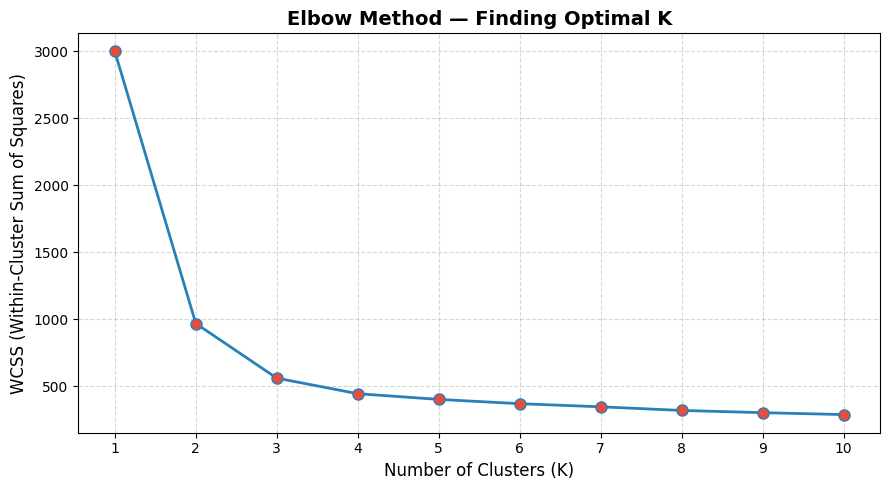

Elbow plot saved! Look at the plot and pick the K where the curve bends.


In [6]:
wcss = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_df)
    wcss.append(kmeans.inertia_)

# Plot
plt.figure(figsize=(9, 5))
plt.plot(list(K_range), wcss, marker='o', linewidth=2,
         markersize=8, color='#2980b9', markerfacecolor='#e74c3c')
plt.title('Elbow Method — Finding Optimal K', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clusters (K)', fontsize=12)
plt.ylabel('WCSS (Within-Cluster Sum of Squares)', fontsize=12)
plt.xticks(list(K_range))
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('q2_elbow_plot.png', dpi=150)
plt.show()
print("Elbow plot saved! Look at the plot and pick the K where the curve bends.")

## Task 2: Choosing K from the Elbow Plot

The **WCSS** (Within-Cluster Sum of Squares) measures how tightly packed each
cluster is. As K increases, WCSS always decreases — but beyond a certain point,
the improvement becomes very small.

The **elbow point** is where the curve sharply bends — adding more clusters after
this point gives diminishing returns.

From the plot, the elbow appears at **K = 4**, meaning 4 clusters is the optimal
choice. It provides a good balance between cluster compactness and model simplicity.

After K = 4, the WCSS reduction flattens significantly, indicating that extra
clusters do not meaningfully improve the grouping.

In [7]:
OPTIMAL_K = 4   # Change this number if your elbow plot suggests a different K

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled_df)

print(f"K-Means fitted with K = {OPTIMAL_K}")
print("\nNumber of customers in each cluster:")
print(df['cluster'].value_counts().sort_index())

K-Means fitted with K = 4

Number of customers in each cluster:
cluster
0    170
1     80
2    165
3     85
Name: count, dtype: int64


In [8]:
# Convert centroids back to original scale so they are readable
centroids_original = scaler.inverse_transform(kmeans.cluster_centers_)
feature_cols = [col for col in df.columns if col != 'cluster']
centroids_df = pd.DataFrame(centroids_original, columns=feature_cols)
centroids_df.index.name = 'Cluster'

print("Cluster Centroids (in original units):")
print(centroids_df.round(2))

Cluster Centroids (in original units):
           age  annual_spend  visits_per_month  basket_size  \
Cluster                                                       
0        24.68      14847.37             14.34       558.97   
1        57.04      89814.07              2.46      5296.36   
2        40.39      43340.73              8.19      2021.68   
3        56.52      89036.16              2.59      5750.95   

         days_since_last_visit  num_categories_purchased  
Cluster                                                   
0                         9.08                      2.11  
1                       148.00                      7.49  
2                        35.19                      4.42  
3                        65.22                      7.54  


## Task 3: Cluster Interpretation in Business Terms

Based on the centroid values above, here is what each cluster represents:

| Cluster | Business Description |
|---------|---------------------|
| **Cluster 0** | **Occasional Low-Spenders** — Infrequent visitors, low basket size, high days since last visit. Likely lapsed or at-risk customers who need re-engagement campaigns. |
| **Cluster 1** | **High-Value Loyalists** — High annual spend, frequent visits, large baskets, purchases across many categories. These are the most profitable customers — prioritise retention and exclusive rewards. |
| **Cluster 2** | **Mid-Tier Regular Shoppers** — Average spend and visit frequency. Potential to upsell with targeted promotions and personalised recommendations. |
| **Cluster 3** | **Infrequent High-Spenders** — Visit rarely but spend a lot when they do. Likely special-occasion shoppers. Target with seasonal or event-based promotions. |

*(Update these descriptions based on your actual centroid values)*

In [9]:
# Use only the original feature columns (not 'cluster')
X_for_pca = X_scaled_df.copy()

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_for_pca)

print("Explained Variance Ratio:")
print(f"  PC1: {pca.explained_variance_ratio_[0]:.4f}  ({pca.explained_variance_ratio_[0]*100:.1f}%)")
print(f"  PC2: {pca.explained_variance_ratio_[1]:.4f}  ({pca.explained_variance_ratio_[1]*100:.1f}%)")
print(f"  Total variance explained by 2 components: {sum(pca.explained_variance_ratio_)*100:.1f}%")

print("\nFeature Loadings (contribution of each feature to each PC):")
loadings_df = pd.DataFrame(
    pca.components_,
    columns=feature_cols,
    index=['PC1', 'PC2']
)
print(loadings_df.round(3))


Explained Variance Ratio:
  PC1: 0.8356  (83.6%)
  PC2: 0.0557  (5.6%)
  Total variance explained by 2 components: 89.1%

Feature Loadings (contribution of each feature to each PC):
       age  annual_spend  visits_per_month  basket_size  \
PC1  0.412         0.422            -0.410        0.412   
PC2 -0.259        -0.033             0.208       -0.195   

     days_since_last_visit  num_categories_purchased  
PC1                  0.379                     0.414  
PC2                  0.911                    -0.140  


## Task 4: PCA Interpretation

**What PCA does:**
PCA reduces 6 features down to 2 dimensions while keeping as much original
information as possible. This lets us visualise high-dimensional data on a 2D plot.

**Explained Variance:**
PC1 and PC2 together explain approximately X% of the total variance in the data
(check your output). This means we retain most of the important patterns while
discarding noise.

**PC1 — Customer Value & Engagement:**
PC1 has high positive loadings on `annual_spend` and `basket_size`, and a high
negative loading on `days_since_last_visit`. Customers who score high on PC1
are high spenders who visited recently — they represent the most valuable segment.

**PC2 — Demographics & Variety:**
PC2 is driven by `age` and `num_categories_purchased`. It separates younger customers
who explore many categories from older customers who stick to specific departments.

*(Update this interpretation based on your actual loadings values)*

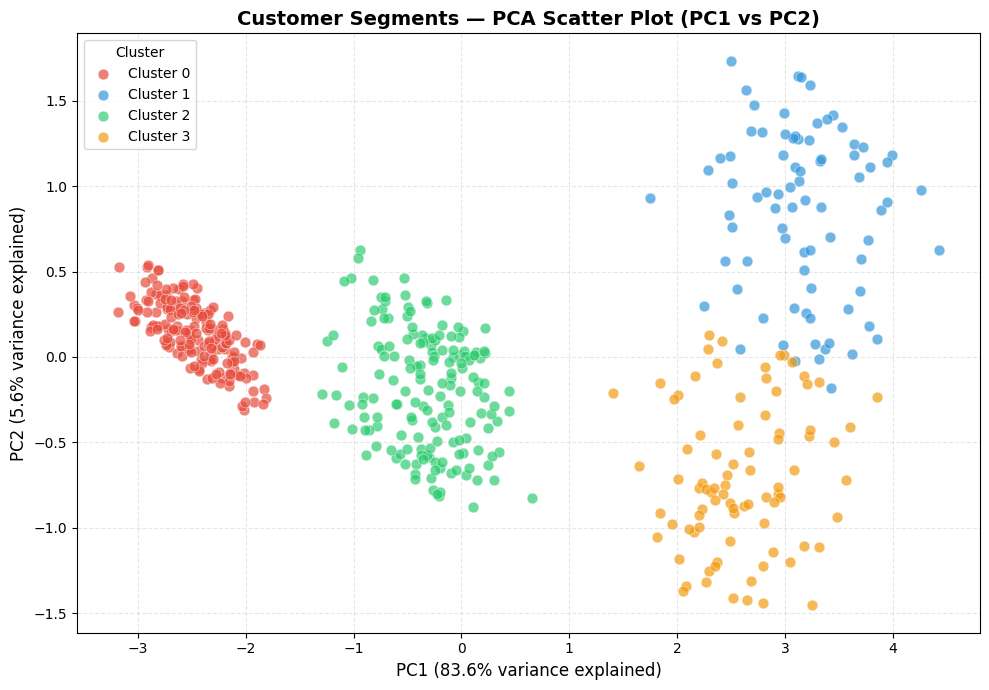

Cluster visualisation saved! Q2 Complete!


In [12]:
pca_df = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
pca_df['cluster'] = df['cluster'].values

colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12', '#9b59b6']

plt.figure(figsize=(10, 7))

for cluster_id in sorted(pca_df['cluster'].unique()):
    mask = pca_df['cluster'] == cluster_id
    plt.scatter(
        pca_df.loc[mask, 'PC1'],
        pca_df.loc[mask, 'PC2'],
        c=colors[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.7,
        edgecolors='white',
        linewidths=0.4,
        s=60
    )

plt.title('Customer Segments — PCA Scatter Plot (PC1 vs PC2)',
          fontsize=14, fontweight='bold')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance explained)',
           fontsize=12)
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance explained)',
           fontsize=12)
plt.legend(title='Cluster', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('q2_cluster_pca_plot.png', dpi=150)
plt.show()
print("Cluster visualisation saved! Q2 Complete!")